In [29]:
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from nltk import ne_chunk, pos_tag, word_tokenize
from nltk.tree import Tree
from fuzzywuzzy import fuzz


In [30]:
pip install fuzzywuzzy

Note: you may need to restart the kernel to use updated packages.


In [36]:
import nltk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')


[nltk_data] Downloading package punkt to C:\Users\ÖRNEK
[nltk_data]     AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ÖRNEK AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to C:\Users\ÖRNEK
[nltk_data]     AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping chunkers\maxent_ne_chunker.zip.
[nltk_data] Downloading package words to C:\Users\ÖRNEK
[nltk_data]     AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\words.zip.


True

# Entity Extractor

In [31]:
class EntityExtractor(BaseEstimator, TransformerMixin):
  def __init__(self):
    pass
  def extract_entities(self, text):
    chunked = ne_chunk(pos_tag(word_tokenize(text)))
    entities = []
    for chunk in chunked:
      if isinstance(chunk, Tree):
        entities.append(" ".join([token for token, pos in chunk.leaves()]))
    return entities
  def transform(self, documents):
    return [self.extract_entities(doc) for doc in documents]


# ENTITY PAIRS

In [32]:
class EntityPairs(BaseEstimator, TransformerMixin):
  def pairs(self, document):
    return list(itertools.permutations(set(document), 2))

  def transform(self, documents):
      return [self.pairs(doc) for doc in documents]


# GRAPH CONSTRUCTOR

In [33]:
class GraphExtractor(BaseEstimator, TransformerMixin):
  def __init__(self):
    self.G = nx.Graph()

  def transform(self, documents):
    for doc in documents:
      for first, second in doc:
        if self.G.has_edge(first, second):
          self.G.edges[first, second]['weight'] += 1
        else:
          self.G.add_edge(first, second, weight=1)
    return self.G


# SAMPLE TEXT DATA 

### sample 1

In [34]:
documents = [
  """No, it wasn’t Louis Pasteur. Back in 1886, Frans von Soxhlet, a German agricultural chemist, was the first person to suggest that milk sold to the public be pasteurized. The term “pasteurization” of course is derived from Louis Pasteur’s pioneering work on the destruction of microbes through heat treatment, but Pasteur’s area of interest was wine and beer, not milk. Actually, Pasteur didn’t even really invent pasteurization. The fact that heat treatment made foods safer was known long before Pasteur, but the French chemist was the first to provide an explanation for the phenomenon. Pasteur realized that spoilage was due to chemical reactions initiated by living microbes, and that the reason heat treatment prevented spoilage was because of its destructive effect on these living organisms. If wine or beer turned sour, Pasteur maintained, it was because of contamination by acid-producing rogue yeasts after the alcohol producing yeast had done its job. Heating of beer or wine would then destroy these invaders and preserve the beverage. Indeed, after the Franco-Prussian War of 1870, Pasteur, a noted French patriot, created his “beer of revenge” which would serve as a testimonial to the superiority of French brewing techniques over anything the Prussians could muster. Heat-treated French beer would keep indefinetly while Prussian beer would go cloudy with time.

As far as beer went, this was mostly a cosmetic, not a health issue. But milk presented an altogether different scenario. Typhoid and scarlet fever, diphtheria, tuberculosis and various diarrheal diseases were all capable of being transmitted through the consumption of milk. But it seems that until 1886, when von Soxhlet made his suggestion, nobody thought of pasteurizing milk on a large scale. And what a difference pasteurization made! In 1891, one in every four infants in New York City died, many from drinking tainted milk. This dropped to about one in fourteen when pasteurization was introduced. The advent of this life-saving technology, though, was not without its critics. Some argued that heat treatment destroyed vital nutrients in milk and produced a “burnt” flavour. Amazingly, the controversy about the pros and cons of pasteurization continues to this day.

Milk contains some 100,000 naturally occurring compounds, and some of these certainly undergo chemical changes with heat. But that does not mean that these changes have any health consequence. There is a lot of bluster from raw milk advocates about pasteurization impairing the nutritional merits of milk, but the arguments are not backed by evidence. There is plenty of evidence on the other hand about unpasteurized milk causing disease. While raw milk from an individual farm, where cleanliness is scrupulously maintained, is likely to be safe, milk pooled from many farms, as is the usual case today, can well harbour a range of bacteria. Until someone finds a way of preventing cows from defecating, pasteurization is the way to go. Heating milk to 72 degress C for 15 seconds (so-called high temperature/short time treatment) or to 138 degrees C for 2 seconds (ultra high temperature treatment) saves lives. """
]


### sample 2

In [41]:
documents1 = [
  "Barack Obama met Angela Merkel in Berlin.",
  "Angela Merkel met Joe Biden.",
  "Joe Biden visited Berlin last week.",
  "Barack Obama went to Washington."
]


# RUN THE PIPELINE

In [39]:
import nltk

# New versions of NLTK (3.9+)
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

# Classic versions of NLTK
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')

# Required for both versions
nltk.download('words')


[nltk_data] Downloading package punkt_tab to C:\Users\ÖRNEK
[nltk_data]     AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ÖRNEK AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\ÖRNEK AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping chunkers\maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package punkt to C:\Users\ÖRNEK
[nltk_data]     AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ÖRNEK AİLESİ\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_

True

In [48]:
entity_extractor = EntityExtractor()
pairs = EntityPairs()
graph_builder = GraphExtractor()

entities = entity_extractor.transform(documents)
pairs_list = pairs.transform(entities)
G = graph_builder.transform(pairs_list)

# Replace print(nx.info(G)) with:
print(f"Graph Info:\nNodes: {G.number_of_nodes()}\nEdges: {G.number_of_edges()}")
print("Nodes:", G.nodes())
print("Edges:", G.edges(data=True))


Graph Info:
Nodes: 10
Edges: 45
Nodes: ['Louis Pasteur', 'Milk', 'New York City', 'Pasteur', 'German', 'French', 'Frans', 'Prussian', 'Soxhlet', 'Typhoid']
Edges: [('Louis Pasteur', 'Milk', {'weight': 2}), ('Louis Pasteur', 'New York City', {'weight': 2}), ('Louis Pasteur', 'Pasteur', {'weight': 2}), ('Louis Pasteur', 'German', {'weight': 2}), ('Louis Pasteur', 'French', {'weight': 2}), ('Louis Pasteur', 'Frans', {'weight': 2}), ('Louis Pasteur', 'Prussian', {'weight': 2}), ('Louis Pasteur', 'Soxhlet', {'weight': 2}), ('Louis Pasteur', 'Typhoid', {'weight': 2}), ('Milk', 'New York City', {'weight': 2}), ('Milk', 'Pasteur', {'weight': 2}), ('Milk', 'German', {'weight': 2}), ('Milk', 'French', {'weight': 2}), ('Milk', 'Frans', {'weight': 2}), ('Milk', 'Prussian', {'weight': 2}), ('Milk', 'Soxhlet', {'weight': 2}), ('Milk', 'Typhoid', {'weight': 2}), ('New York City', 'Pasteur', {'weight': 2}), ('New York City', 'German', {'weight': 2}), ('New York City', 'French', {'weight': 2}), ('New Y

# CENTRALITY METRICS

In [49]:
degree_centrality = nx.degree_centrality(G)
print("Degree centrality:", degree_centrality)


Degree centrality: {'Louis Pasteur': 1.0, 'Milk': 1.0, 'New York City': 1.0, 'Pasteur': 1.0, 'German': 1.0, 'French': 1.0, 'Frans': 1.0, 'Prussian': 1.0, 'Soxhlet': 1.0, 'Typhoid': 1.0}


# EGO GRAPH (FOCUS ON A SPECIFIC ENTITY)

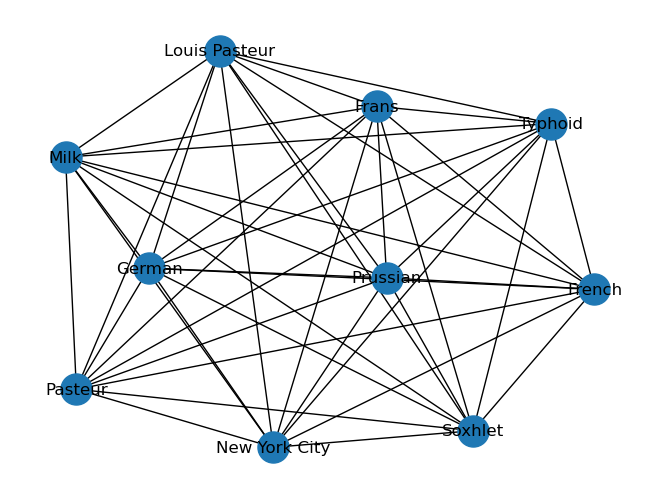

In [54]:
ego = nx.ego_graph(G, "German")
nx.draw(ego, with_labels=True, node_size=500)
plt.show()


# SIMPLE FUZZY ENTITY RESOLUTION

In [60]:
def similarity(n1, n2):
  return fuzz.partial_ratio(n1, n2)

print("Similarity between 'Pasteur' and 'Soxhlet':",
   similarity("Soxhlet", "Milk"))


Similarity between 'Pasteur' and 'Soxhlet': 25
